<big><big>001: data pre-processing walkthrough</big></big>
<a id='index'></a><br>

- [part 0: pre-processing for a single object](#steps)
    - [alert processor](#alertp)
    - [photometry processor](#photo)
    - [data preprocessor](#pre)
    - [images](#images)
    - [alert selection](#alert)
    - [spectra](#spectra)
- [part 1: pre-processing a dataset](#transient)

In [26]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/Users/junell/Documents/AppleCider')

from AppleCider.preprocess.data_preprocessor import AlertProcessor, PhotometryProcessor, DataPreprocessor, SpectraProcessor
from AppleCider.preprocess.data_preprocessor import DataSorter
from AppleCider.preprocess.transient_dataset import TransientDataset

import AppleCider.preprocess.plot_data as plot_data

In [2]:
SEDM_dataset = pd.read_csv('/Users/junell/Documents/AppleCider/SEDM_dataset.csv')
SEDM_dataset

,obj_id,type
0,ZTF18aatfxtd,SN Ia
1,ZTF18aawppyt,SN Ia
2,ZTF18aakpnyt,AGN
3,ZTF18aclgopa,AGN
4,ZTF18adjoimi,AGN
...,...,...
7493,ZTF18aajlxao,AGN
7494,ZTF18abmwqkr,AGN
7495,ZTF19aadzgnt,AGN
7496,ZTF19aaesrrd,AGN


<big>part 0: pre-processing for a single object</big>

<br>
<i>a) alert processor, b) photometry processor</i>

<a id='steps'></a>
<a id='alertp'></a>
<a id='photo'></a><br>
<i><small>[back to index](#index)</small></i>

In [27]:
obj_SN = 'ZTF20aambbfn'  # other cute SN Ia: ZTF20aarasxl, ZTF20aafjjqj, ZTF22abtbijr
#obj_SN = 'ZTF17aaajnki'

data_dir = '/Users/junell/Documents/AppleCider_Data/SEDM_folder' ## where all the obj folders are saved to

## loading data from folder
## change column names, add object id, object type to make photo_df
photo_df = PhotometryProcessor.process_csv(obj_SN, SEDM_dataset, data_dir)
metadata_df, images = AlertProcessor.get_process_alerts(obj_SN, data_dir)

In [5]:
photo_df[:2]

,obj_id,jd,mjd,mag,magerr,snr,limiting_mag,filter,type
0,ZTF20aambbfn,2.458887e+06,58886.242130,19.611099,0.285659,6.18730,19.445999,ztfg,SN Ia
1,ZTF20aambbfn,2.458885e+06,58884.489363,19.048901,0.134265,6.29451,19.866400,ztfr,SN Ia


In [6]:
metadata_df[:2]

,jd,fid,pid,diffmaglim,pdiffimfilename,programpi,programid,candid,isdiffpos,tblid,...,clrmed,clrrms,neargaia,neargaiabright,maggaia,maggaiabright,exptime,drb,drbversion,obj_id
0,2.458885e+06,2,1130489363715,19.866436,ztf_20200205489340_000752_zr_c10_o_q2_scimrefd...,Kulkarni,3,1130489363715015004,t,4,...,0.742,0.327286,0.976307,-999.0,18.066233,-999.0,30.0,0.996355,d6_m7,ZTF20aambbfn
1,2.458887e+06,1,1132243023715,19.475851,ztf_20200207243021_000752_zg_c10_o_q2_scimrefd...,Kulkarni,1,1132243023715015001,t,1,...,0.601,0.294263,1.226615,-999.0,18.066233,-999.0,30.0,0.976252,d6_m7,ZTF20aambbfn


In [7]:
## sort by date (JD)
## add metadata missing from photometry
photo_df, metadata_df = photo_df.sort_values(by='jd'), metadata_df.sort_values(by='jd')
photo_df = PhotometryProcessor.add_metadata_to_photometry(photo_df, metadata_df)
photo_df[:2]

,obj_id,jd,mjd,mag,magerr,snr,limiting_mag,filter,type
0,ZTF20aambbfn,2.458885e+06,58884.489363,19.048901,0.134265,6.29451,19.866400,ztfr,SN Ia
1,ZTF20aambbfn,2.458887e+06,58886.242130,19.611099,0.285659,6.18730,19.445999,ztfg,SN Ia


BUUUUT, these give us the full light curve and all the images. we only want the early alerts....

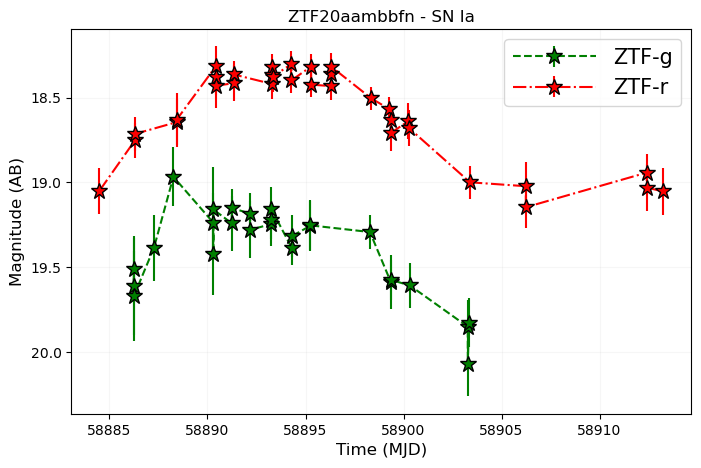

In [8]:
plot_data.plot_photometry_magnitude(photo_df)

<i>c) images</i>

<a id='images'></a>
<i><small>[back to index](#index)</small></i>

55
Selected index: [ 3 54]
Image number: 3


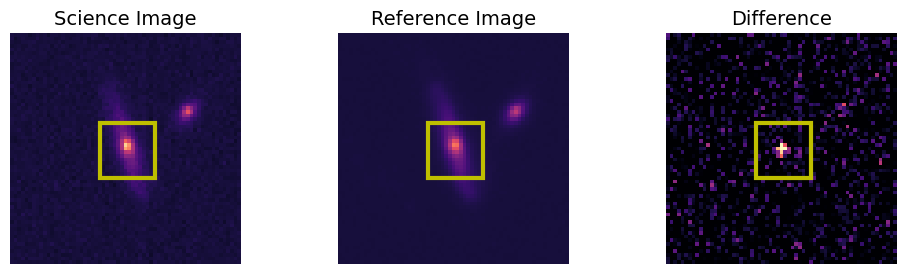

Image number: 54


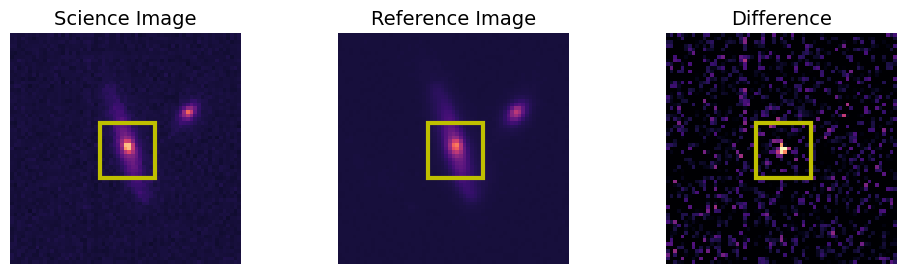

In [9]:
print(len(images))

n = 2
selected_index = np.round(np.linspace(3, len(images) - 1, n)).astype(int)
print('Selected index:', selected_index)
for i in selected_index:
    print('Image number:', i)
    plot_data.plot_image(images[i], vmin_set=0.004, vmax_set=0.099)

<i>d) data preprocessor</i>

<a id='pre'></a>
<i><small>[back to index](#index)</small></i>

In [10]:
## convert magnitude to flux
photo_df = DataPreprocessor.convert_photometry(photo_df)
photo_df[:1]

,obj_id,mjd,flux,flux_error,filter,type,jd
0,ZTF20aambbfn,0.0,87.184596,10.781477,ztfr,SN Ia,2.458885e+06


In [11]:
## cut down to only early-ish photometry
max_ = min(photo_df['mjd'].max(), 10)
photo_df = photo_df[photo_df['mjd'] <= max_]
photo_df[:2]

,obj_id,mjd,flux,flux_error,filter,type,jd
0,ZTF20aambbfn,0.000000,87.184596,10.781477,ztfr,SN Ia,2.458885e+06
1,ZTF20aambbfn,1.752766,51.946980,13.667336,ztfg,SN Ia,2.458887e+06


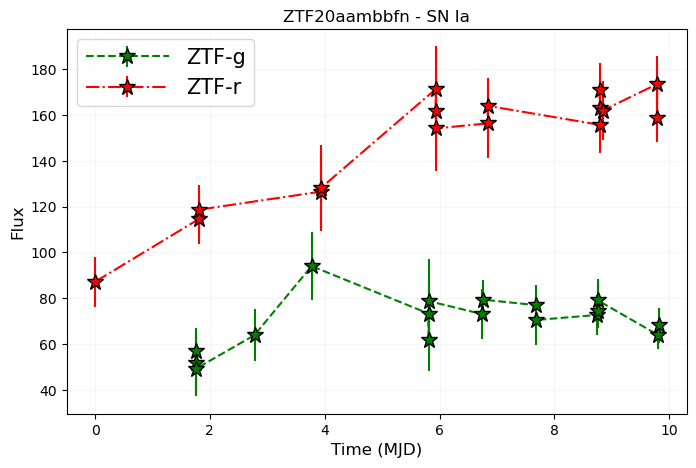

In [12]:
plot_data.plot_photometry_magnitude(photo_df)

<a id='alert'></a><br>

<i>e) alert selection<i>

we'll create some faux alerts by taking valid indices in `metadata_df` and then use them to match the photometry, metadata, and images to the correct time

<i><small>[back to index](#index)</small></i>

In [13]:
metadata_df = metadata_df[metadata_df['jd'] <= photo_df['jd'].max()]
metadata_df = DataPreprocessor.preprocess_metadata(metadata_df)
metadata_df_norm = metadata_df.drop(columns=['jd'])

## and we will slice this into "alerts" 
alert_indices = list(range(len(metadata_df) // 2, len(metadata_df))) 
print("valid alert indices: ", alert_indices, '\n')

## but 15 slices of one object's light curve seems steep, so let's reduce the alerts
if len(alert_indices) > 3:
    alert_indices = np.round(np.linspace(len(metadata_df) // 2, len(metadata_df) - 1, 7)).astype(int)

print("our faux alert indices will be: ", alert_indices)

valid alert indices:  [14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28] 

our faux alert indices will be:  [14 16 17 19 20 22 23 25 26 28]


Photometry at index: 14


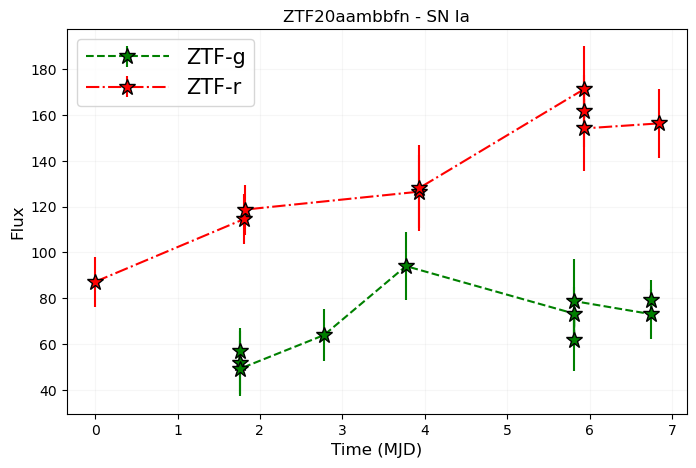

Photometry at index: 16


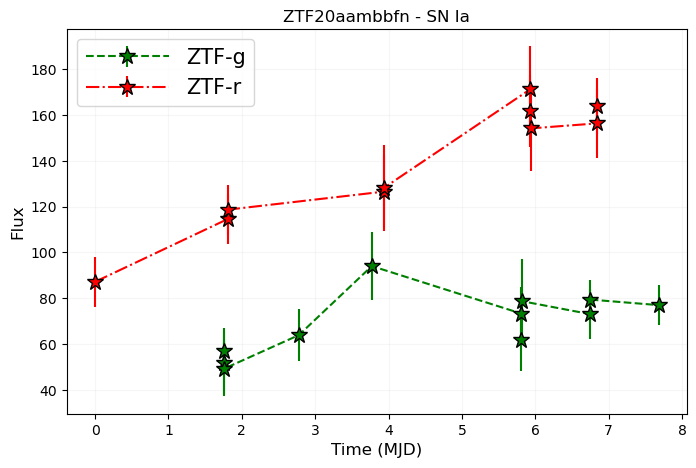

Photometry at index: 17


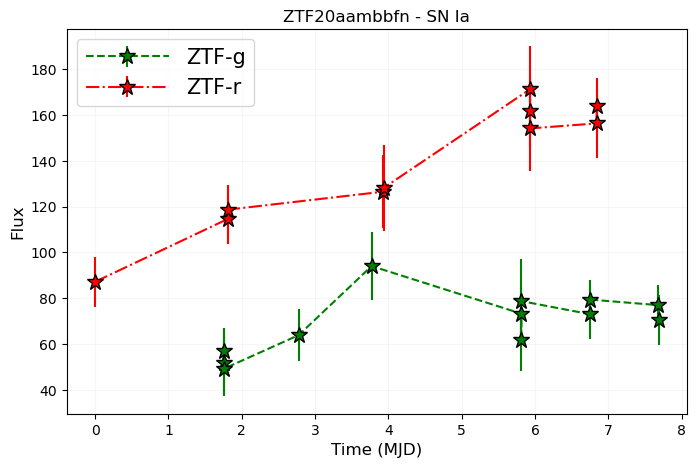

Photometry at index: 19


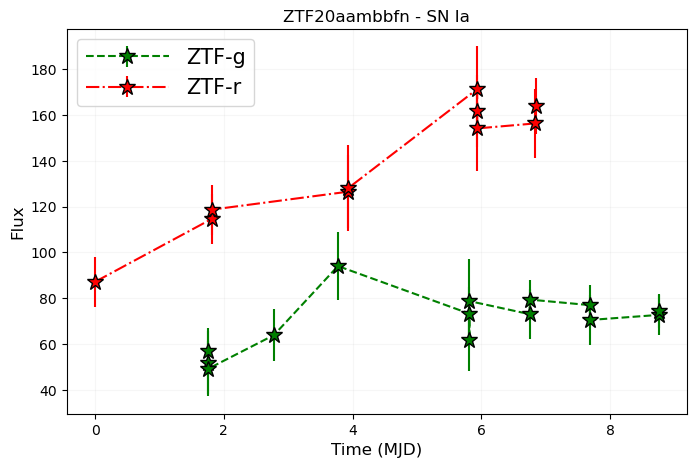

Photometry at index: 20


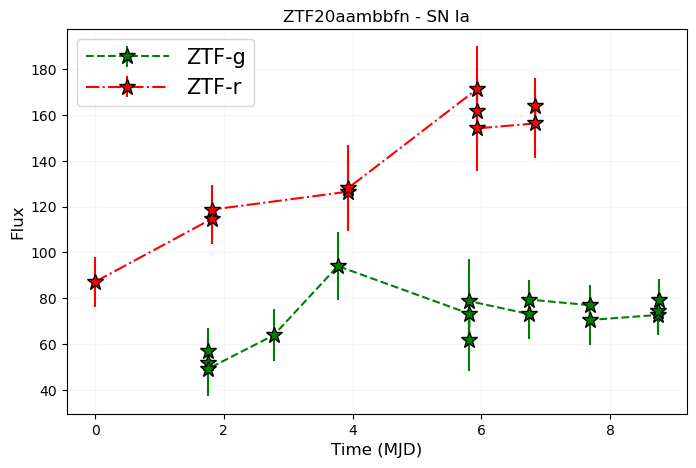

Photometry at index: 22


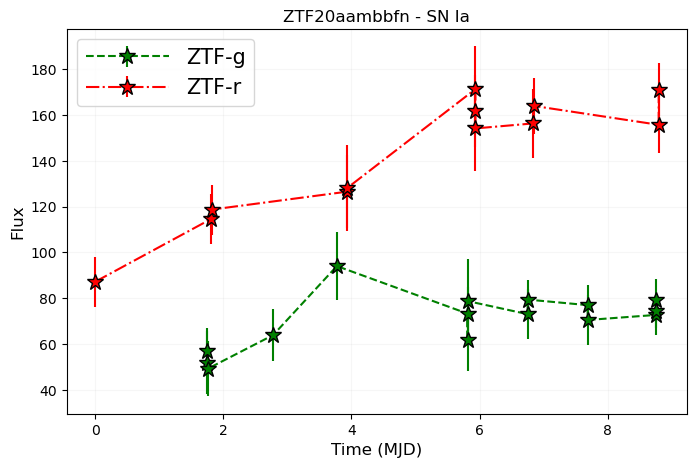

Photometry at index: 23


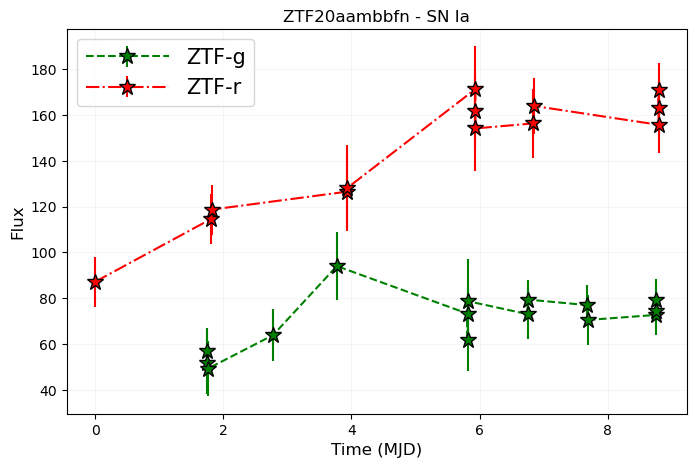

Photometry at index: 25


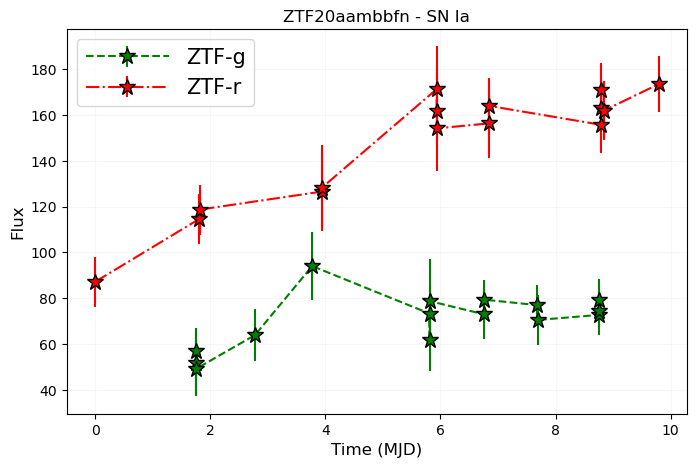

Photometry at index: 26


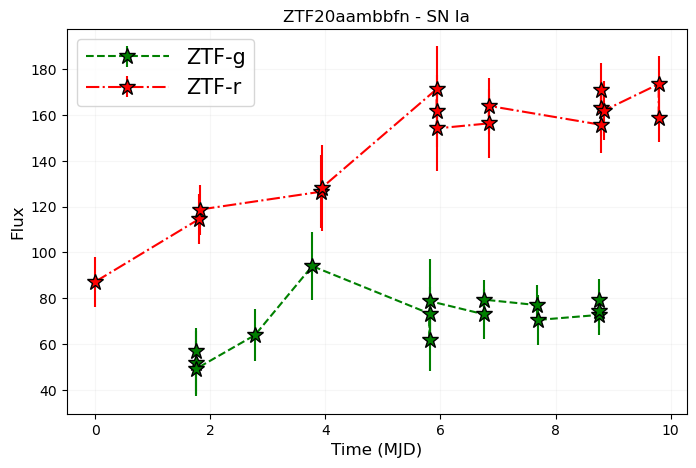

Photometry at index: 28


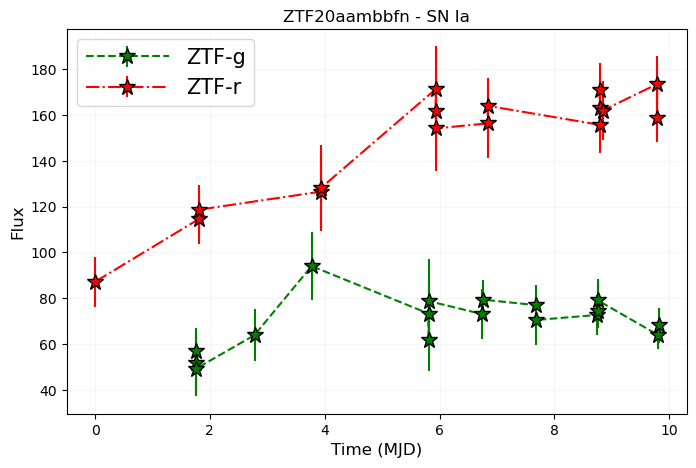

In [14]:
for i in alert_indices:
    print('Photometry at index:', i)
    photo_ready = DataPreprocessor.cut_photometry(photo_df, metadata_df, i, max_mjd=10)
    plot_data.plot_photometry_magnitude(photo_ready)

<i>f) spectra</i>

<a id='spectra'></a>

<i><small>[back to index](#index)</small></i>

In [15]:
SpectraProcessor.get_spectra_df(obj_SN, data_dir)

,ZTFID,wavelength,flux,observed_at,observed_at_mjd,instrument_name,telescope_name,data_length
0,ZTF20aambbfn,3776.7,4.792000e-17,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
1,ZTF20aambbfn,3802.3,4.812000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
2,ZTF20aambbfn,3827.9,7.101000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
3,ZTF20aambbfn,3853.4,4.830000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
4,ZTF20aambbfn,3879.0,5.129000e-16,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
...,...,...,...,...,...,...,...,...
209,ZTF20aambbfn,9121.0,1.317000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
210,ZTF20aambbfn,9146.6,1.373000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
211,ZTF20aambbfn,9172.1,1.368000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3
212,ZTF20aambbfn,9197.7,1.330000e-15,2020-02-11T05:48:56,58890.242315,SEDM,Palomar 1.5m,3


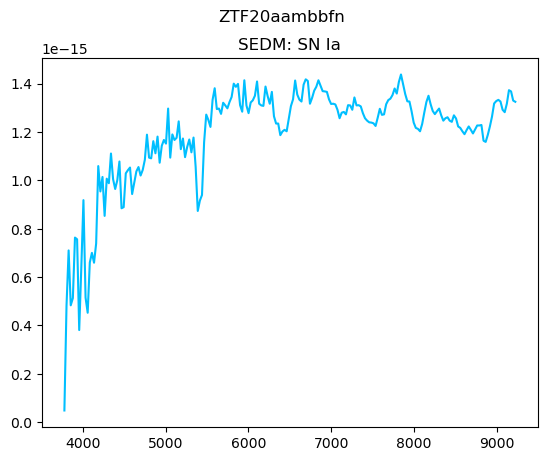

In [16]:
plot_data.plot_spectra(obj_SN, SEDM_dataset, data_dir)

In [17]:
## preprocess spectra
spectra = SpectraProcessor.read_spectra_csv(obj_SN, data_dir)
spectra = SpectraProcessor.preprocess_spectra(spectra)
spectra

array([[-5.152986  , -5.06692   , -4.9808536 , ...,  0.24690495,
         0.21799059,  0.18907624]], dtype=float32)

***

<big><big>part 1: pre-processing the dataset</big></big>

<a id='transient'></a>
<i><small>[back to index](#index)</small></i>

In [28]:
TEST_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_test'
TRAIN_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_train'

CLASSES = ['SN Ia','SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']

SEDM_dataset = SEDM_dataset[SEDM_dataset['type'].isin(CLASSES)]
SEDM_dataset['type'].value_counts()

type
SN Ia                     4982
SN II                      509
SN IIP                     474
Cataclysmic                298
AGN                        180
SN IIn                     168
SN Ic                      116
SN Ib                      110
SN IIb                      85
Tidal Disruption Event      42
Name: count, dtype: int64

In [41]:
## only get to say sedm_spec_only=False since we already filtered out the non-SEDM spectra
test_df, train_df = DataSorter.sample_objects_from_df(SEDM_dataset, 'type', CLASSES, data_dir, n_test=390, n_train=3090,
                                                      sedm_spec_only=False, downsample_SNIa=True)


training:  2161 objects
training:  421 objects


In [43]:
test_df['type'].value_counts()

type
SN Ia                     94
SN IIP                    81
SN II                     79
Cataclysmic               43
SN Ic                     30
AGN                       25
SN IIn                    21
SN Ib                     19
SN IIb                    18
Tidal Disruption Event    11
Name: count, dtype: int64

In [45]:
train_df['type'].value_counts()

type
SN Ia                     506
SN II                     430
SN IIP                    393
Cataclysmic               255
AGN                       155
SN IIn                    147
SN Ib                      91
SN Ic                      86
SN IIb                     67
Tidal Disruption Event     31
Name: count, dtype: int64

In [20]:
#test_df.to_csv('/Users/junell/Documents/AppleCider/test_df.csv', index=False)
#train_df.to_csv('/Users/junell/Documents/AppleCider/train_df.csv', index=False)

test_df = pd.read_csv('/Users/junell/Documents/AppleCider/test_df.csv')
train_df = pd.read_csv('/Users/junell/Documents/AppleCider/train_df.csv')

`TransientDataset` includes all of the preprocessing steps showed in <i>part 0</i>. you can choose the maximum MJD, whether to normalize the light curve, and whether to include spectra

<u>notes:</u>
- `Failed alert index slice. [obj_id]: 1 point in light curve, alert index 0, when mjd <= 10.`: the object will end up having a huge tensor of zeros for photometry. this object will be skipped and no alerts for it will be saved. if you do want to save them and include objects with 1 point, set `normalize_light_curve=False`, and comment out `ln[55]-ln[64]`, `ln[65]-[69]` from `TransientDataset`

- `[obj_id] failed min photometry requirements. skip alert at index [i]!`: the loop will skip that alert index and go to the object's next alert (if there is one). if you want to include objects with 1 point,  set `normalize_light_curve=False`, and comment out `ln[55]-ln[64]`, `ln[65]-[69]` from `TransientDataset`.

<i><small>[back to index](#index)</small></i>

In [23]:
dataset_test = TransientDataset(TEST_DATA_PATH, base_path=data_dir, max_mjd=10, normalize_light_curve=True, include_spectra=True)
dataset_test.preprocess_data(test_df, data_dir, max_mjd=10)

dataset_test.preprocess_and_save()

Loading data:   0%|          | 0/421 [00:00<?, ?it/s]

Failed alert index slice. No alert saved for ZTF18aarikzk: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18aagpzjk: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF23aadtzse: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF19aaxkhxw: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18abvgghe: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18aapzqup: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF20aborzxc: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18aatpqxq: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF19acvrjzd: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18abbikrz: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18aajswer: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF20aauodrj: 1 point in light curve.
Fail

Processing Objects:   0%|          | 0/2575 [00:00<?, ?it/s]

In [22]:
dataset_train = TransientDataset(TRAIN_DATA_PATH, base_path=data_dir, max_mjd=10, normalize_light_curve=True, include_spectra=True)
dataset_train.preprocess_data(train_df, data_dir, max_mjd=10)

dataset_train.preprocess_and_save()

Loading data:   0%|          | 0/2161 [00:00<?, ?it/s]

Failed alert index slice. No alert saved for ZTF18aamyexb: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF19acgpwkz: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18abvnsmh: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18aaqlksk: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18aakfabl: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF19aanbpus: 1 point in light curve.
ZTF22abybbud failed min photometry requirements. skip alert at index 1!
Failed alert index slice. No alert saved for ZTF18aavskyg: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18abdribr: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18aamfsxv: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18aakkrjm: 1 point in light curve.
Failed alert index slice. No alert saved for ZTF18aaabltn: 1 point in light curve.
Failed alert in

Processing Objects:   0%|          | 0/12857 [00:00<?, ?it/s]

In [24]:
# make dataframe of object IDs with associated alert file names, and clasification 
data_test, data_train = DataSorter.create_df_of_object_alerts_in_dataset(test_df, train_df, TEST_DATA_PATH, TRAIN_DATA_PATH)

In [25]:
#data_train.to_csv('/Users/junell/Documents/AppleCider/data_train.csv', index=False)
#data_test.to_csv('/Users/junell/Documents/AppleCider/data_test.csv', index=False)

In [ ]:
objects_with_low_photometry = [ 'ZTF18aagpzjk', 'ZTF23aadtzse', 'ZTF19aaxkhxw', 'ZTF18abvgghe', 'ZTF18aapzqup', 'ZTF20aborzxc', 'ZTF18aatpqxq', 'ZTF19acvrjzd', 'ZTF18abbikrz', 'ZTF18aajswer','ZTF20aauodrj', 'ZTF21aaekeqv', 'ZTF19abzqrzf', 'ZTF18aavtklk', 'ZTF20aaqepvb', 'ZTF19aaksxgp', 'ZTF20aauvbez', 'ZTF19aakirwj', 'ZTF20aawrmcm', 'ZTF23aaqixpx',
                                'ZTF18acapkod', 'ZTF18aawwbqm', 'ZTF19aafltef', 'ZTF19aapreis','ZTF18aamyexb','ZTF19acgpwkz','ZTF18abvnsmh','ZTF18aaqlksk','ZTF18aakfabl','ZTF19aanbpus',
                                'ZTF18aavskyg','ZTF18abdribr','ZTF18aamfsxv','ZTF18aakkrjm','ZTF18aaabltn','ZTF20acnviht','ZTF18aaqpowv','ZTF18aawpwlf','ZTF18aauvyug','ZTF21abkajar','ZTF18aaegvyd','ZTF18aaquvvq','ZTF18aakebhi','ZTF18aamgcbt','ZTF18aawgrxz','ZTF18aazjflo',
                                'ZTF18aanlzzf','ZTF18aazhtcv','ZTF18aasszwr','ZTF18aarbgrh','ZTF17aaburzk','ZTF18aaadtdc','ZTF18aaakpsa','ZTF18aaaokus','ZTF18aabicqe','ZTF18aadkjmo','ZTF18aamnrdd','ZTF18aanjzkp','ZTF18aaoecso','ZTF18aapifti','ZTF18aartjod','ZTF18aarybyq','ZTF18abccqmd','ZTF18abcyzif','ZTF18abfzixe','ZTF18abjdnoh','ZTF18abjlyzc','ZTF18ablgtdi',
                                'ZTF18abllrvn','ZTF18ablvxdg','ZTF18abokhip','ZTF18aboronz','ZTF18abrfchj','ZTF18absxczg','ZTF18abujubn','ZTF18abumesx','ZTF18abuqkdh','ZTF18abvmlow','ZTF18abvoyen','ZTF18abwisaz','ZTF18abywcoi','ZTF18acauijl','ZTF18acauwik','ZTF18acbvhfl','ZTF18acckpzv', 'ZTF18acmwewv',
                                'ZTF18acsvycn','ZTF18acswkeb','ZTF18actxchc','ZTF18acvbigh','ZTF19aaaizjh','ZTF19aaeopgw','ZTF19aaezale','ZTF19aaiohcc','ZTF19aakswrb','ZTF19aanpcep','ZTF19aaozugz','ZTF19aapreza','ZTF19aarpymc','ZTF19aatmgjs','ZTF19aatyrpj','ZTF19aavgukt','ZTF19aayurjv','ZTF19abcyqqg',
                                'ZTF19abdviwl','ZTF19abkxeft','ZTF19abmmksy','ZTF19abonixj','ZTF19abyihtb','ZTF19aceckmm','ZTF19ackjvtl','ZTF19acvkibv','ZTF19acwbhih','ZTF19acyggzu','ZTF19acykaae','ZTF19adaxzax','ZTF20aacbyoh','ZTF20aaspvan','ZTF20aatqene','ZTF20aauoipy','ZTF20aawbxmt','ZTF20aazvump','ZTF20ackzfvn','ZTF21aaaokyp',
                                'ZTF21abccaue','ZTF22aaacvyy','ZTF22aaaehtn','ZTF22aaaeilq','ZTF22aaafrcl','ZTF22abajudi','ZTF22abegjtx','ZTF22abykdbm','ZTF22abyoomc','ZTF22acaipkl','ZTF22acaunur','ZTF23aaabzea','ZTF23aacgjgl','ZTF23aadndfn','ZTF23aadtrzd','ZTF23aaisxic','ZTF23abfvoig','ZTF23absscow',
                                'ZTF18aakebod','ZTF18aajbvyg','ZTF19aafmwcu','ZTF19aaphntn','ZTF18abrcvbu','ZTF18aaxeoqk','ZTF22abbrxbz','ZTF20aagloch','ZTF21acqwbsn','ZTF18aajjhkq','ZTF22ablpkba','ZTF18abfbbyh','ZTF18aavrmlf','ZTF22aaqrszt','ZTF19acsbxgw','ZTF18aamvfeb','ZTF24aacyttg', 'ZTF18abcdzyc', 'ZTF18aavryhc', 'ZTF18abupgps', 'ZTF18aatwqed', 
                                'ZTF18aatrtkc', 'ZTF18aamxads', 'ZTF23abtowce', 'ZTF20achatyv', 'ZTF18aajkrxi', 'ZTF18abifioh', 'ZTF18abfdupq', 'ZTF18aavuzhe', 'ZTF23aaaehem']                         

example of a processed alerts from the same object:


In [29]:
alert2 = np.load(os.path.join(TEST_DATA_PATH, 'ZTF23ablaxwm_alert_2.npy'), allow_pickle=True).item()
alert2

{'obj_id': 'ZTF23ablaxwm',
 'photometry': array([[ 0.      , -1.      ,  0.      ,  0.      ],
        [ 2.983993,  1.      ,  0.      ,  0.      ]]),
 'metadata': sgscore1       0.500000
 sgscore2       0.061958
 distpsnr1      8.656558
 distpsnr2      9.132485
 ra           137.828969
 dec           -1.547559
 nmtchps        4.000000
 sharpnr        0.459000
 scorr         19.890968
 sky            0.433513
 Name: 2, dtype: float64,
 'images': array([[[ 1.58249810e-02,  1.57130603e-02,  2.78793578e-03],
         [ 1.58273652e-02,  1.56605821e-02,  7.38026435e-03],
         [ 1.54198268e-02,  1.57247446e-02, -1.31249297e-02],
         ...,
         [ 1.51175940e-02,  1.56476237e-02, -8.84008687e-03],
         [ 1.64482091e-02,  1.56905688e-02,  8.10398441e-03],
         [ 1.48699321e-02,  1.55939227e-02, -7.83801731e-03]],
 
        [[ 1.55298989e-02,  1.57633238e-02, -9.22187977e-03],
         [ 1.49987936e-02,  1.58209316e-02, -2.13259310e-02],
         [ 1.56009970e-02,  1.57578960

In [30]:
alert3 = np.load(os.path.join(TEST_DATA_PATH, 'ZTF23ablaxwm_alert_3.npy'), allow_pickle=True).item()
alert3

{'obj_id': 'ZTF23ablaxwm',
 'photometry': array([[ 0.        , -1.1272212 ,  0.        ,  0.        ],
        [ 2.983993  ,  1.30322488,  0.        ,  0.        ],
        [ 5.0211227 , -0.17600368,  0.        ,  0.        ]]),
 'metadata': sgscore1       0.500000
 sgscore2       0.061958
 distpsnr1      8.701714
 distpsnr2      9.180644
 ra           137.828964
 dec           -1.547546
 nmtchps        4.000000
 sharpnr        0.243000
 scorr         36.398117
 sky            0.104527
 Name: 3, dtype: float64,
 'images': array([[[ 0.01508264,  0.01552736, -0.00641728],
         [ 0.01565188,  0.01542829,  0.00650649],
         [ 0.01583889,  0.01547341,  0.01081758],
         ...,
         [ 0.0151148 ,  0.01559061, -0.01022579],
         [ 0.01538987,  0.01552482,  0.00057698],
         [ 0.01513663,  0.01566056, -0.01312202]],
 
        [[ 0.01547685,  0.01547908,  0.00256806],
         [ 0.01512776,  0.01568464, -0.0129306 ],
         [ 0.01527219,  0.01580202, -0.01088095],
      

In [36]:
alert4 = np.load(os.path.join(TRAIN_DATA_PATH, 'ZTF24abbenwl_alert_7.npy'), allow_pickle=True).item()
alert4

{'obj_id': 'ZTF24abbenwl',
 'photometry': array([[ 0.        ,  0.25803231, -0.4472136 ,  0.        ],
        [ 0.9109491 ,  0.38826682, -0.4472136 ,  0.        ],
        [ 0.9894329 ,  0.51244154, -0.4472136 ,  0.        ],
        [ 1.9510996 ,  0.54108505, -0.4472136 ,  0.        ],
        [ 1.9764236 ,  0.52533168, -0.4472136 ,  0.        ],
        [ 2.9503935 , -2.2251574 ,  2.23606798,  0.        ]]),
 'metadata': sgscore1      0.283458
 sgscore2      0.500000
 distpsnr1     5.404588
 distpsnr2     6.374115
 ra            6.374800
 dec          20.242937
 nmtchps      22.000000
 sharpnr       0.427000
 scorr        24.876194
 sky          -0.126166
 Name: 7, dtype: float64,
 'images': array([[[ 0.01275453,  0.01263713, -0.00081874],
         [ 0.01239291,  0.01276796, -0.0024443 ],
         [ 0.01336783,  0.01272393,  0.01282465],
         ...,
         [ 0.01289813,  0.01264794,  0.01094556],
         [ 0.01295292,  0.01265507,  0.00289501],
         [ 0.01252248,  0.0126803